Healthcare Risk Prediction — Machine Learning vs Neural Networks

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

1. Load the data using pandas

In [2]:
#Load the data using pandas
df = pd.read_csv('/content/drive/MyDrive/Dataset/healthcare_dataset.csv')

2. Explore the dataset structure

In [60]:
df.columns

Index(['patient_id', 'age', 'bmi', 'exercise_hours_per_week', 'smoker',
       'blood_pressure', 'diabetes'],
      dtype='object')

In [61]:
df.head()

,patient_id,age,bmi,exercise_hours_per_week,smoker,blood_pressure,diabetes
0,1,31,18.3,1.5,0,119.1,0
1,2,44,26.3,3.1,0,120.5,0
2,3,43,24.2,4.8,0,130.3,0
3,4,32,25.0,6.0,0,119.5,0
4,5,28,22.1,4.2,1,127.4,0


In [62]:
# a. shape of the dataset
df.shape

(6000, 7)

In [63]:
# b. column types
df.dtypes

,0
patient_id,int64
age,int64
bmi,float64
exercise_hours_per_week,float64
smoker,int64
blood_pressure,float64
diabetes,int64


In [64]:
# missing values
df.isnull().sum()

,0
patient_id,0
age,0
bmi,0
exercise_hours_per_week,0
smoker,0
blood_pressure,0
diabetes,0


3. Basic statistical analysis

In [129]:
df.drop(columns=['patient_id']).describe()

,age,bmi,exercise_hours_per_week,smoker,blood_pressure,diabetes
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,51.107333,25.995267,3.012800,0.307000,134.239733,0.090333
std,19.522722,4.960541,1.491802,0.461288,11.234260,0.286683
min,18.000000,15.000000,0.000000,0.000000,94.000000,0.000000
25%,34.000000,22.500000,2.000000,0.000000,126.000000,0.000000
50%,51.000000,26.100000,3.000000,0.000000,134.200000,0.000000
75%,68.000000,29.400000,4.000000,1.000000,142.325000,0.000000
max,84.000000,44.900000,8.500000,1.000000,169.700000,1.000000


In [127]:
df['diabetes'].value_counts()

,count
diabetes,
0,5458
1,542


4. Data visualization

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

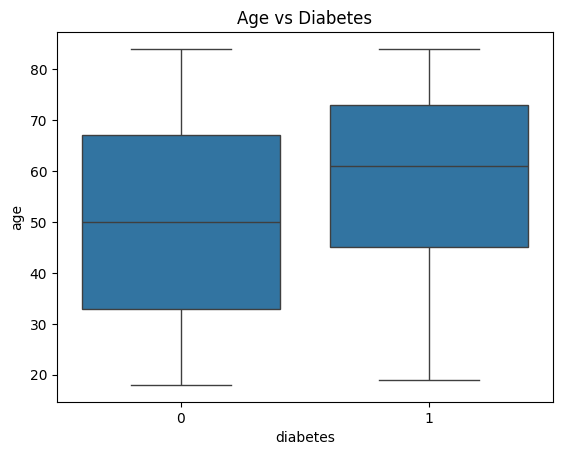

In [68]:
sns.boxplot(x='diabetes',y='age', data = df)
plt.title("Age vs Diabetes")
plt.show()

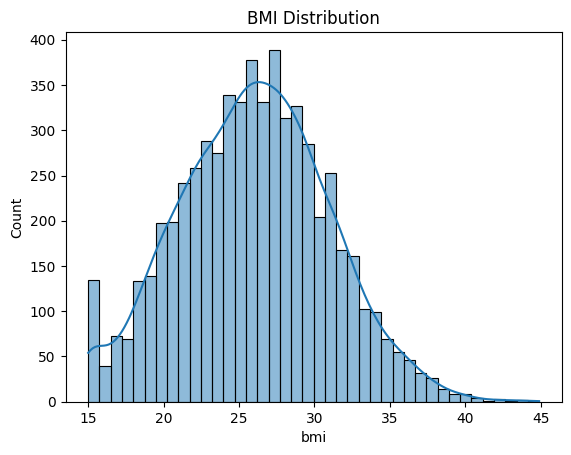

In [69]:
sns.histplot(df['bmi'], kde=True)
plt.title("BMI Distribution")
plt.show()

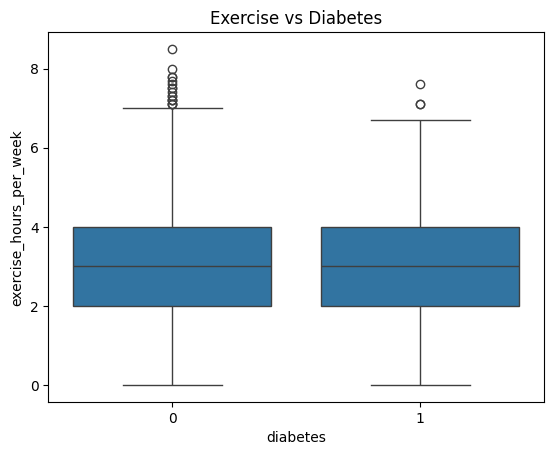

In [70]:
sns.boxplot(x='diabetes', y='exercise_hours_per_week', data=df)
plt.title("Exercise vs Diabetes")
plt.show()

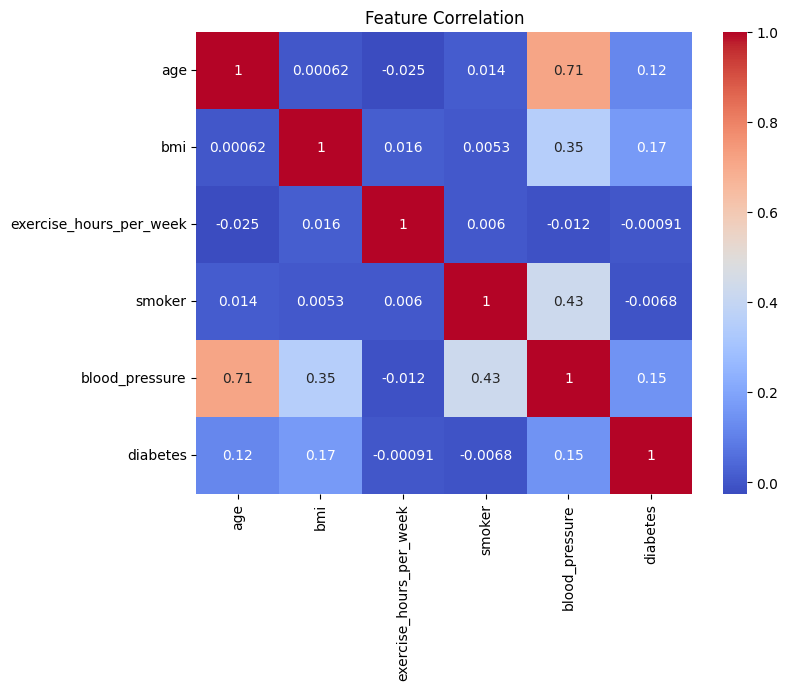

In [75]:
plt.figure(figsize=(8,6))

corr = df.drop(columns=['patient_id']).corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Feature Correlation")
plt.show()

Part 2 - Machine Learning classification model

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [4]:
X = df.drop(columns=['patient_id', 'diabetes'])
y = df['diabetes']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [47]:
class_weight = {0:1, 1:7}
model = LogisticRegression(class_weight=class_weight,C=0.8,solver = 'liblinear', random_state = 42)
model.fit(X_train_scaled, y_train)

LogisticRegression(C=0.8, class_weight={0: 1, 1: 7}, random_state=42,
                   solver='liblinear')

In [48]:
y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [49]:
threshold = 0.5
y_pred = (y_prob > threshold).astype(int)

In [50]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.7741666666666667


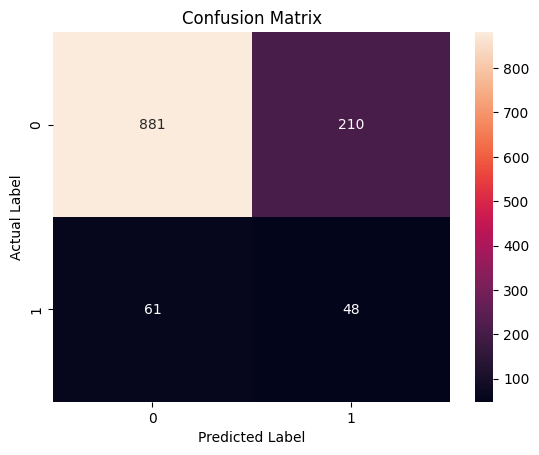

Confusion Matrix:
 [[881 210]
 [ 61  48]]


In [51]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix')
plt.show()
print("Confusion Matrix:\n", cm)

In [52]:
# Precision, Recall, F1
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.81      0.87      1091
           1       0.19      0.44      0.26       109

    accuracy                           0.77      1200
   macro avg       0.56      0.62      0.56      1200
weighted avg       0.87      0.77      0.81      1200



Part 3 - Neural Network Model

In [64]:
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [65]:
# 2. Features & target
X = df.drop(columns=['patient_id', 'diabetes'])
y = df['diabetes']


In [66]:
# 3. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [67]:
# 4. Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [68]:
# 5. Build Neural Network
model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [69]:
# 6. Compile model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [70]:
# 7. Train model
class_weight = {0:1, 1:7}
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weight,
    verbose=1
)

Epoch 1/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6490 - loss: 1.0478 - val_accuracy: 0.8052 - val_loss: 0.6193
Epoch 2/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7958 - loss: 0.9759 - val_accuracy: 0.7625 - val_loss: 0.5194
Epoch 3/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7448 - loss: 0.9451 - val_accuracy: 0.7719 - val_loss: 0.4977
Epoch 4/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7432 - loss: 0.9418 - val_accuracy: 0.7573 - val_loss: 0.5085
Epoch 5/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7456 - loss: 0.9386 - val_accuracy: 0.7594 - val_loss: 0.5114
Epoch 6/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7383 - loss: 0.9359 - val_accuracy: 0.7490 - val_loss: 0.5152
Epoch 7/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7568 - loss: 0.9323 - val_accuracy: 0.7437 - val_loss: 0.5177
Epoch 8/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7333 - loss: 0.9315 - val_accuracy: 0.

In [71]:
# 8. Evaluate model
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7717 - loss: 0.4768
Test Accuracy: 0.7716666460037231


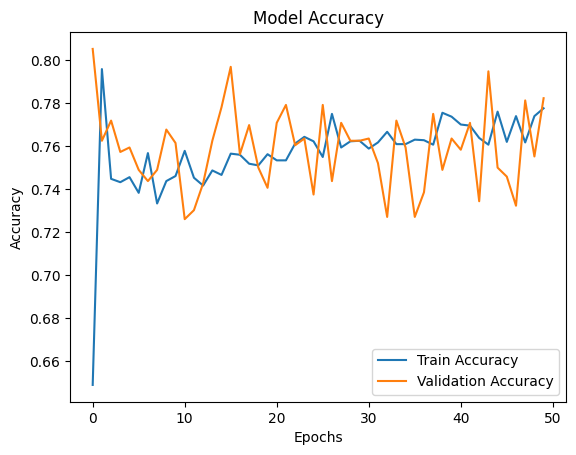

In [72]:
# 9. Plot training performance
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Model Accuracy')
plt.show()

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


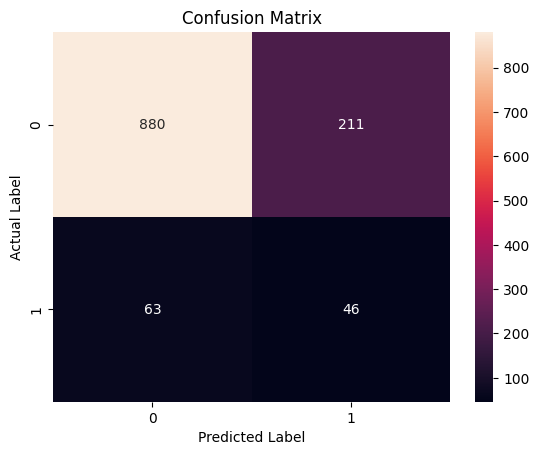

Confusion Matrix:
 [[880 211]
 [ 63  46]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.81      0.87      1091
           1       0.18      0.42      0.25       109

    accuracy                           0.77      1200
   macro avg       0.56      0.61      0.56      1200
weighted avg       0.86      0.77      0.81      1200



In [76]:
from sklearn.metrics import confusion_matrix, classification_report

# Predict probabilities
y_prob = model.predict(X_test)

y_pred = (y_prob > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)
plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix')
plt.show()

# Evaluation
print("Confusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(y_test, y_pred))